In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [101]:
df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [103]:
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = df['SalePrice']

In [104]:
corr = df[['GrLivArea','BedroomAbvGr','FullBath','SalePrice']].corr()
print(corr)

              GrLivArea  BedroomAbvGr  FullBath  SalePrice
GrLivArea      1.000000      0.521270  0.630012   0.708624
BedroomAbvGr   0.521270      1.000000  0.363252   0.168213
FullBath       0.630012      0.363252  1.000000   0.560664
SalePrice      0.708624      0.168213  0.560664   1.000000


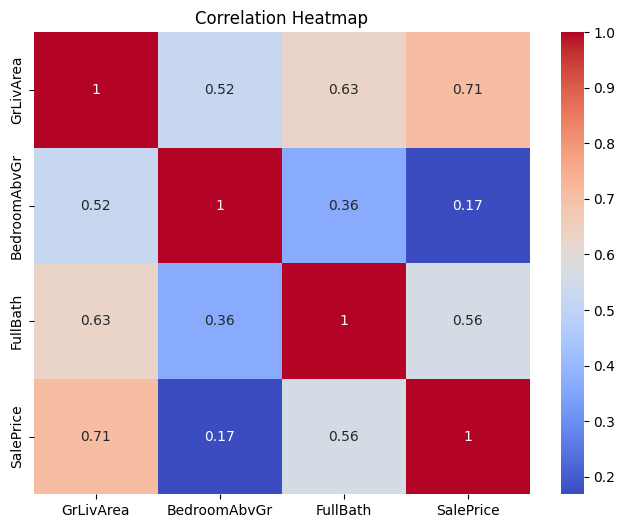

In [105]:
plt.figure(figsize=(8,6))

sns.heatmap(corr,annot=True,cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

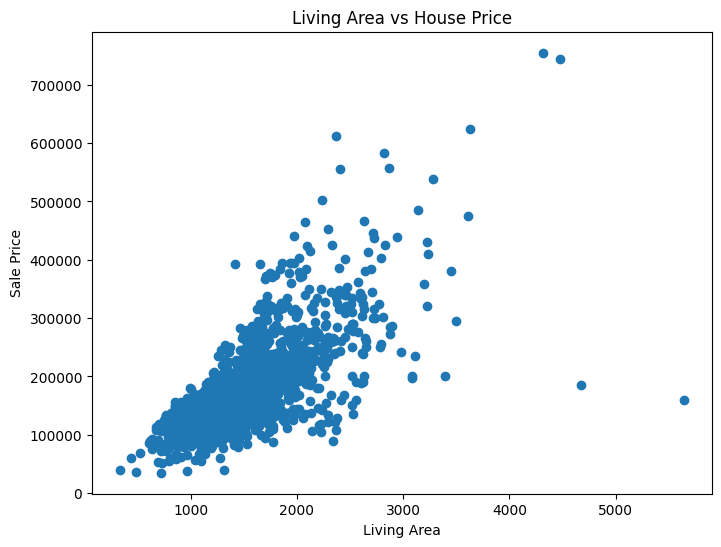

In [106]:
plt.figure(figsize=(8,6))

plt.scatter(df['GrLivArea'], df['SalePrice'])

plt.xlabel("Living Area")
plt.ylabel("Sale Price")
plt.title("Living Area vs House Price")
plt.show()

In [107]:
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = df['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(
  X,y,test_size=0.2,random_state=42)

In [108]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [109]:
predictions = model.predict(X_test)

In [110]:
mae = mean_absolute_error(y_test,predictions)
mse = mean_squared_error(y_test,predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 35788.061292436294
MSE : 2806426667.247853
RMSE : 52975.71771338122
R2 Score : 0.6341189942328371


In [111]:
results = pd.DataFrame({
    'Actual': y_test,'Predicted': predictions})

results.head(10)

,Actual,Predicted
892,154500,113410.672553
1105,325000,305081.877759
413,115000,135904.785630
522,159000,205424.675641
1036,315500,227502.683490
614,75500,121157.480796
218,311500,205577.980566
1160,146000,183787.203783
649,84500,121157.480796
887,135500,147219.222332


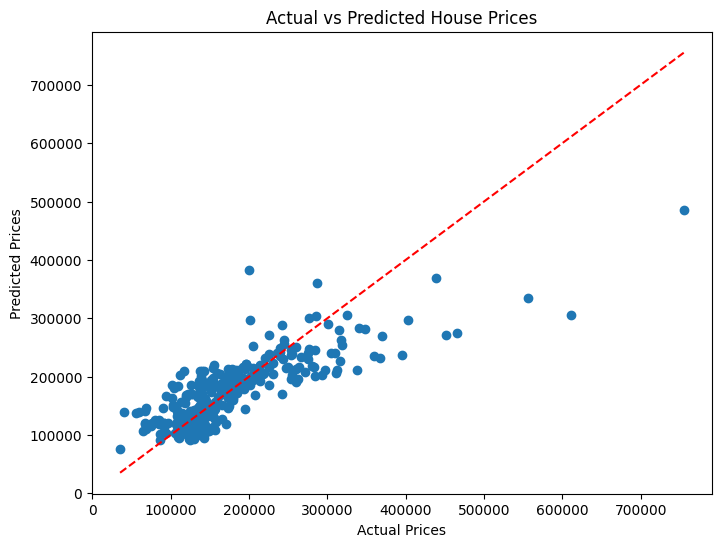

In [112]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

# **Conclusion**

In this project, I developed a House Price Prediction model using the Linear Regression algorithm. The objective was to predict house prices based on three important features: living area, number of bedrooms, and number of bathrooms. Before building the model, I explored the dataset and performed data visualization using scatter plots and correlation analysis to better understand the relationship between the selected features and house prices.

After training and testing the model, its performance was evaluated using MAE, MSE, RMSE, and R² Score. The model achieved an R² Score of 0.634, which indicates that it can explain approximately 63.4% of the variation in house prices. Although only three features were used, the model was able to make reasonably accurate predictions and demonstrated the effectiveness of Linear Regression for regression-based problems.

Through this project, I gained practical knowledge of data preprocessing, feature selection, data visualization, model training, prediction, and performance evaluation. This project helped me strengthen my understanding of Machine Learning concepts and provided valuable hands-on experience in applying Linear Regression to solve a real-world problem.
